# Stream en ObsPy #
## Índice
1. [Introducción a Stream en ObsPy](#1-introducción)
2. [Lectura de datos en un Stream](#2-lectura-de-stream)
3. [Manipulación de Streams y Traces](#3-manipulación)
4. [Visualización de datos en Stream](#4-visualizaciones)
5. [Escritura de datos desde un Stream](#5-escritura-en-stream)
6. [Descarga de datos en un Stream desde repositorios en línea](#6-repositorios)
7. [Eliminación de la respuesta instrumental en un Stream](#7-eliminar-respuesta)

---
## 1. Introducción a Stream en ObsPy<a id="1-introducción"></a>
Fuente: Formatos_datos.py

En ObsPy, los datos sísmicos se manejan principalmente a través de dos objetos: Stream y Trace.

Un Stream es una colección de Trace, donde cada Trace contiene los datos de una serie temporal y su metadata asociada (como la red, estación, ubicación y canal).

Ejemplo de lectura de un archivo MiniSEED:

In [1]:
from obspy import read

In [7]:
st = read('C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/stream/example.mseed')
print(st)

6 Trace(s) in Stream:
IV.BDI..BHE | 2014-04-04T01:33:37.045000Z - 2014-04-04T02:15:10.695000Z | 20.0 Hz, 49874 samples
IV.BDI..BHE | 2014-04-04T02:15:23.535000Z - 2014-04-04T03:08:04.485000Z | 20.0 Hz, 63220 samples
IV.BDI..BHN | 2014-04-04T01:33:43.975000Z - 2014-04-04T02:15:12.125000Z | 20.0 Hz, 49764 samples
IV.BDI..BHN | 2014-04-04T02:15:22.725000Z - 2014-04-04T03:08:10.025000Z | 20.0 Hz, 63347 samples
IV.BDI..BHZ | 2014-04-04T01:33:26.745000Z - 2014-04-04T02:15:11.195000Z | 20.0 Hz, 50090 samples
IV.BDI..BHZ | 2014-04-04T02:15:24.025000Z - 2014-04-04T03:08:16.825000Z | 20.0 Hz, 63457 samples


Un Stream puede contener una o más Trace, y cada Trace tiene atributos como data (los datos) y stats (la metadata).

## 2. Lectura de datos en un Stream<a id="2-lectura-de-stream"></a>
Fuente: Obspy - copia.py

Para leer datos sísmicos desde un archivo, se utiliza la función read de ObsPy.

Ejemplo:

In [17]:
st = read('C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/stream/B082_EHZ.mseed')
print(st)

1 Trace(s) in Stream:
PB.B082..EHZ | 2010-04-04T22:40:42.368400Z - 2010-04-04T22:45:42.358400Z | 100.0 Hz, 30000 samples


Acceso a una Trace dentro de un Stream:

In [18]:
tr = st[0]
print(tr)

PB.B082..EHZ | 2010-04-04T22:40:42.368400Z - 2010-04-04T22:45:42.358400Z | 100.0 Hz, 30000 samples


Visualización de los datos y metadata:

In [19]:
print(tr.data) 

[  49   52   50 ... 6979 7201 7440]


In [20]:
print(tr.stats)  

         network: PB
         station: B082
        location: 
         channel: EHZ
       starttime: 2010-04-04T22:40:42.368400Z
         endtime: 2010-04-04T22:45:42.358400Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 30000
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'M', 'number_of_records': 134, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 68608})


## 3. Manipulación de Streams y Traces <a id="3-manipulación"></a>
Fuente: Formatos_datos.py y Obspy - copia.py

Selección de componentes: Puedes seleccionar trazas específicas dentro de un Stream usando `select`.

In [21]:
st.select(component="Z")

1 Trace(s) in Stream:
PB.B082..EHZ | 2010-04-04T22:40:42.368400Z - 2010-04-04T22:45:42.358400Z | 100.0 Hz, 30000 samples

Copia de datos: Es recomendable hacer una copia del Stream antes de modificarlo.

In [25]:
st2 = st.copy()
tr2 = st2[0]

Procesamiento básico: Operaciones como `detrend`, `taper` y `filter` se aplican directamente sobre el Stream o Trace.

In [26]:
tr2.detrend("linear")
tr2.taper(type="hann", max_percentage=0.05)
tr2.filter("lowpass", freq=0.5)

PB.B082..EHZ | 2010-04-04T22:40:42.368400Z - 2010-04-04T22:45:42.358400Z | 100.0 Hz, 30000 samples

## 4. Visualización de datos en Stream  <a id="4-visualizaciones"></a>
Fuente: Obspy - copia.py

Para graficar los datos de un Stream o Trace, se utiliza el método `plot`.

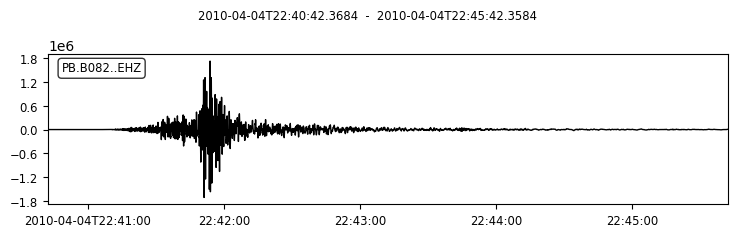

In [28]:
tr.plot();

Personalización de gráficos:

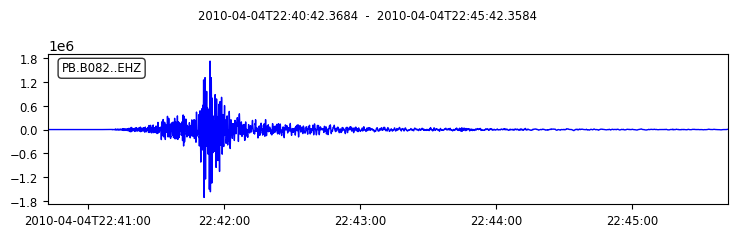

In [29]:
tr.plot(color='b');  # Cambiar el color de la gráfica

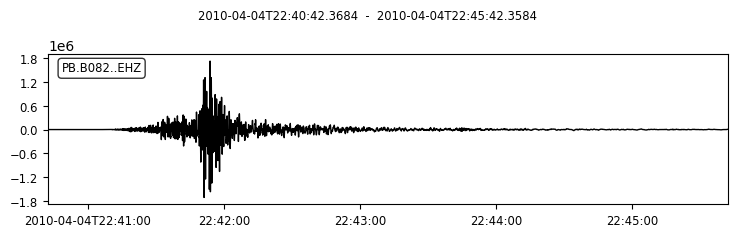

In [31]:
st.plot();

## 5. Escritura de datos desde un Stream <a id="5-ecritura-en-stream"></a>
Fuente: Formatos_datos.py

Para guardar los datos de un Stream en un archivo, se utiliza el método `write`.

Ejemplo de escritura en formato MiniSEED:

In [33]:
st.write("temp.mseed", format="mseed")

Ejemplo de escritura en formato SAC:

In [34]:
st.write("temp.sac", format="sac")

## 6. Descarga de datos en un Stream desde repositorios en línea <a id="6-repositorios"></a>
Fuente: Obspy - copia.py

ObsPy permite descargar datos sísmicos directamente desde repositorios como IRIS utilizando el cliente FDSN.

Ejemplo de descarga de datos:

In [64]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

1 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples


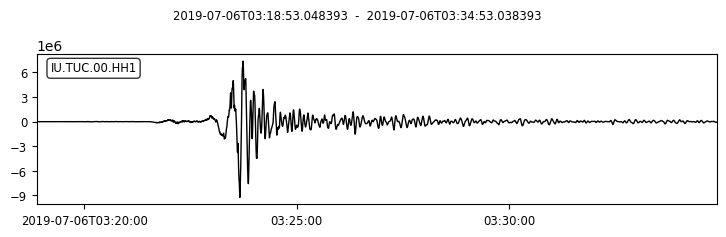

In [65]:
client = Client("IRIS")
st = client.get_waveforms(network="IU", station="TUC", location="00", channel="HH1", 
                          starttime=UTCDateTime("2019-07-06T03:19:53.04") - 60, 
                          endtime=UTCDateTime("2019-07-06T03:19:53.04") + 60*15,
                         attach_response = True)
print(st)
st.plot();

Uso de comodines para descargar múltiples canales:

In [66]:
time = UTCDateTime("2019-07-06T03:19:53.04")
print(time)

2019-07-06T03:19:53.040000Z


In [67]:
starttime = time - 60 
print(starttime)

2019-07-06T03:18:53.040000Z


In [68]:
endtime = time + 60*15
print(endtime)

2019-07-06T03:34:53.040000Z


In [69]:
st = client.get_waveforms(network="IU", station="TUC", location="00", channel="HH*", 
                          starttime=starttime, endtime=endtime,attach_response = True)

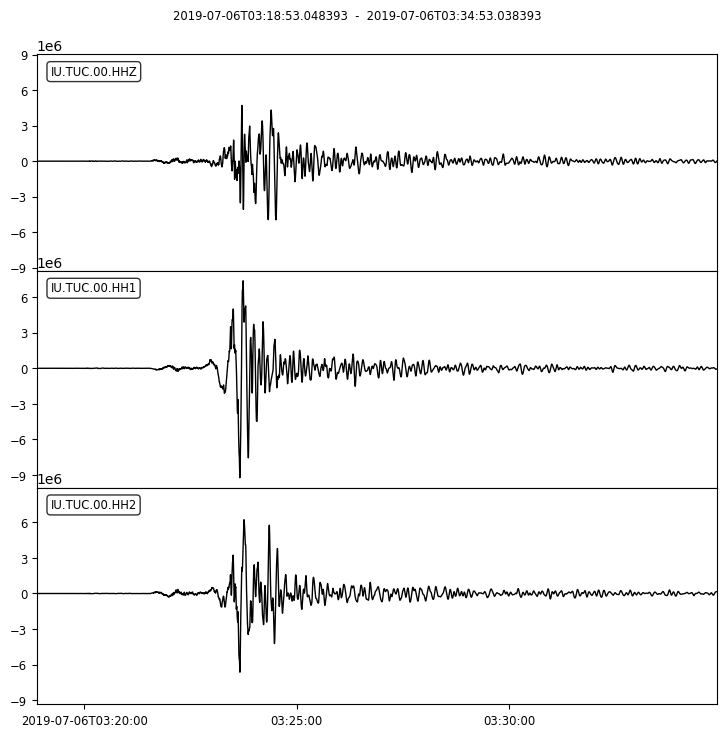

In [70]:
st.plot();

## 7. Eliminación de la respuesta instrumental en un Stream <a id="7-eliminar-respuesta"></a>
Fuente: Obspy - copia.py

Para convertir los datos de "cuentas" a unidades físicas (como velocidad o desplazamiento), es necesario eliminar la respuesta del instrumento.

Ejemplo de eliminación de la respuesta:

In [74]:
time = UTCDateTime("2019-07-06T03:19:53.04")
starttime = time - 60 
endtime = time + 60*15

net = "IU"
sta = "TUC"
loc = "00"
chan = "HH1"

1 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples


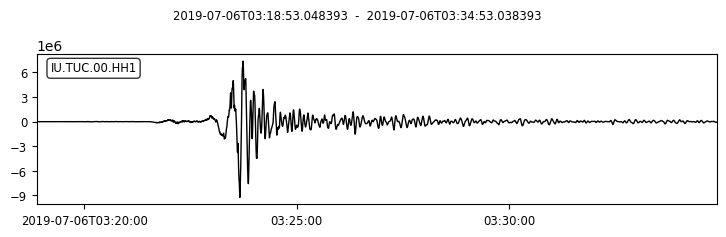

In [75]:
st = client.get_waveforms(net, sta, loc, chan, starttime, endtime, attach_response = True)
print(st)
st.plot();

In [76]:
st_rem = st.copy()  # Copia del Stream original
print(st)
print(st_rem)

1 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples
1 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples


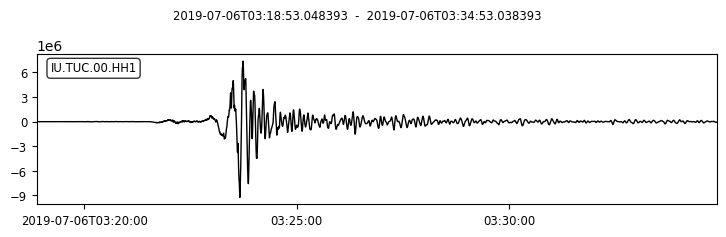

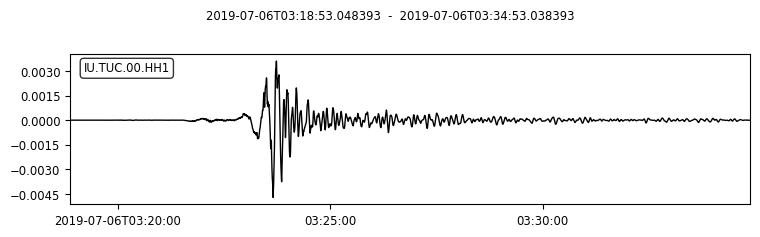

In [77]:
st_rem.remove_response(output = 'VEL') 
st.plot()
st_rem.plot();

Visualización del proceso de eliminación de respuesta:

1 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples

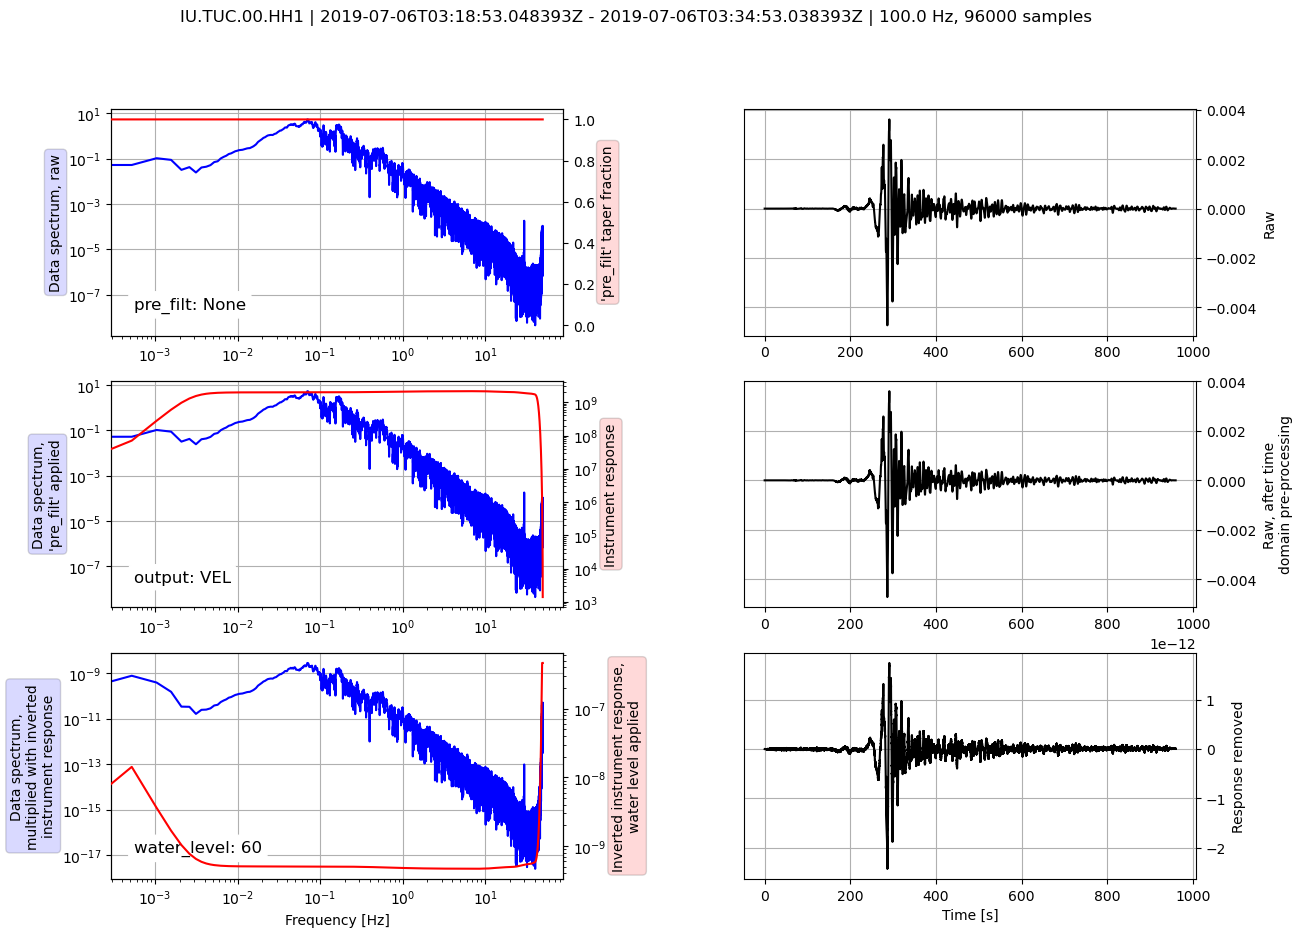

In [78]:
st_rem.remove_response(output="VEL", plot=True)